In [ ]:
from google.colab import files
uploaded = files.upload()

Saving olist_orders_dataset.csv to olist_orders_dataset (1).csv


In [ ]:
import pandas as pd

orders = pd.read_csv('olist_orders_dataset.csv')

print(orders.shape)
print("---")
print(orders.info())
print("---")
print(orders.isnull().sum())

(99441, 8)
---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None
---
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_deli

In [ ]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

#Filter hanya order yang delivered
orders_clean = orders[orders['order_status'] == 'delivered'].copy()

# Cek hasilnya
print(f"Total order awal     : {len(orders)}")
print(f"Order berstatus delivered : {len(orders_clean)}")
print(f"Yang dibuang         : {len(orders) - len(orders_clean)}")
print()
print(orders_clean.dtypes)

Total order awal     : 99441
Order berstatus delivered : 96478
Yang dibuang         : 2963

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


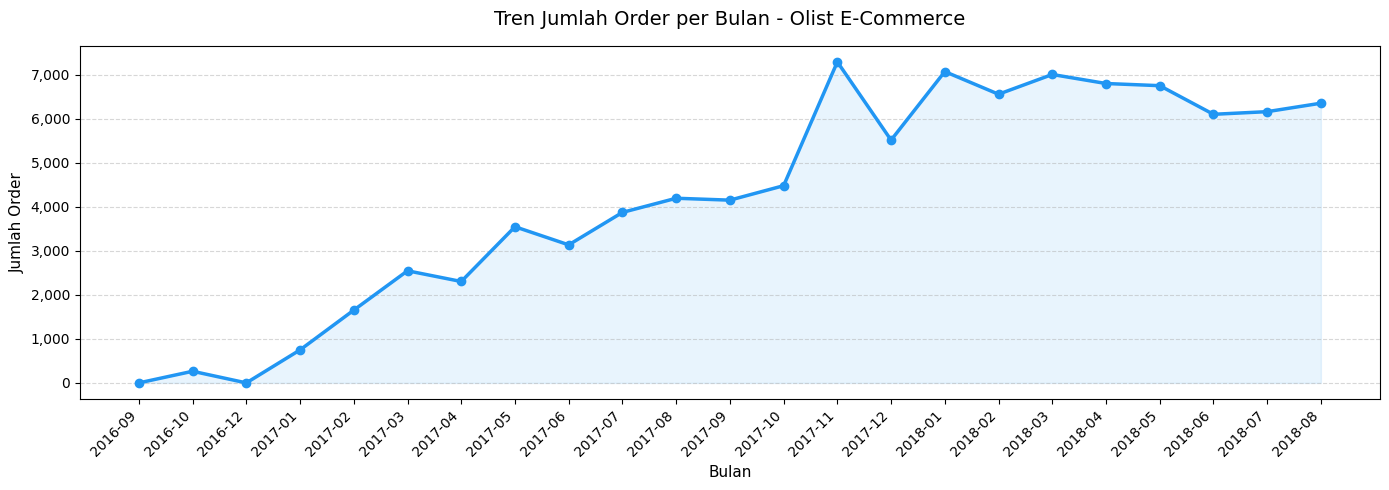

  bulan  jumlah_order bulan_str
2016-09             1   2016-09
2016-10           265   2016-10
2016-12             1   2016-12
2017-01           750   2017-01
2017-02          1653   2017-02
2017-03          2546   2017-03
2017-04          2303   2017-04
2017-05          3546   2017-05
2017-06          3135   2017-06
2017-07          3872   2017-07
2017-08          4193   2017-08
2017-09          4150   2017-09
2017-10          4478   2017-10
2017-11          7289   2017-11
2017-12          5513   2017-12
2018-01          7069   2018-01
2018-02          6555   2018-02
2018-03          7003   2018-03
2018-04          6798   2018-04
2018-05          6749   2018-05
2018-06          6099   2018-06
2018-07          6159   2018-07
2018-08          6351   2018-08


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

#Ekstrak bulan dari tanggal pembelian
orders_clean['bulan'] = orders_clean['order_purchase_timestamp'].dt.to_period('M')

#Hitung jumlah order per bulan
tren_bulanan = orders_clean.groupby('bulan').size().reset_index(name='jumlah_order')

#Ubah ke string
tren_bulanan['bulan_str'] = tren_bulanan['bulan'].astype(str)

#Grafik Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(tren_bulanan['bulan_str'], tren_bulanan['jumlah_order'],
        marker='o', color='#2196F3', linewidth=2.5, markersize=6)

ax.fill_between(tren_bulanan['bulan_str'], tren_bulanan['jumlah_order'],
                alpha=0.1, color='#2196F3')

ax.set_title('Tren Jumlah Order per Bulan - Olist E-Commerce', fontsize=14, pad=15)
ax.set_xlabel('Bulan', fontsize=11)
ax.set_ylabel('Jumlah Order', fontsize=11)
plt.xticks(rotation=45, ha='right')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('tren_bulanan.png', dpi=150)
plt.show()

# Print angkanya juga
print(tren_bulanan.to_string(index=False))

#INSIGHT
1. Tren Pertumbuhan
  Pada Platform Olist mengalami pertumbuhan order yang konsisten dari tahun 2017, dari 750 order pada bulan januari menjadi 4.478 order pada bulan oktober. Sehingga artinya mengalami kenaikan sebesar 497% dalam 10 bulan.
2. Peak Season November 2017
  Terjadi lonjakan signifikan pada November 2017 sebesar 7.289 order dimana +63% vs bulan sebelumnya, hal ini kemungkinan dikarenakan oleh event Black Friday. Hal ini menunjukkan perilaku pembelian pelanggan sangat responsif terhadap promo musiman.
3. Kestabilan pada tahun 2018
  Pada 2018, volume order stabil di kisaran 6.000–7.000/bulan, mengindikasikan platform telah mencapai fase mature dengan customer base yang solid.

In [ ]:
from google.colab import files
uploaded = files.upload()
items = pd.read_csv('olist_order_items_dataset.csv')
print("Items loaded:", items.shape)

Saving olist_order_items_dataset.csv to olist_order_items_dataset (4).csv
Items loaded: (112650, 7)


In [ ]:
import pandas as pd

orders = pd.read_csv('olist_order_items_dataset.csv')

print(orders.shape)
print("---")
print(orders.info())
print("---")
print(orders.isnull().sum())

(112650, 7)
---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB
None
---
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


In [ ]:
uploaded = files.upload()
products = pd.read_csv('olist_products_dataset.csv')
print("Products loaded:", products.shape)

Saving olist_products_dataset.csv to olist_products_dataset (1).csv
Products loaded: (32951, 9)


In [ ]:
import pandas as pd

orders = pd.read_csv('olist_products_dataset.csv')

print(orders.shape)
print("---")
print(orders.info())
print("---")
print(orders.isnull().sum())

(32951, 9)
---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB
None
---
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g   

In [ ]:
#Gabungkan data
df = orders_clean.merge(items, on='order_id', how='inner')
df = df.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')

print(f"Tabel gabungan: {df.shape}")
df[['order_id', 'product_category_name', 'price']].head(5)

Tabel gabungan: (110197, 16)


,order_id,product_category_name,price
0,e481f51cbdc54678b7cc49136f2d6af7,utilidades_domesticas,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,perfumaria,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,automotivo,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,pet_shop,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,papelaria,19.90


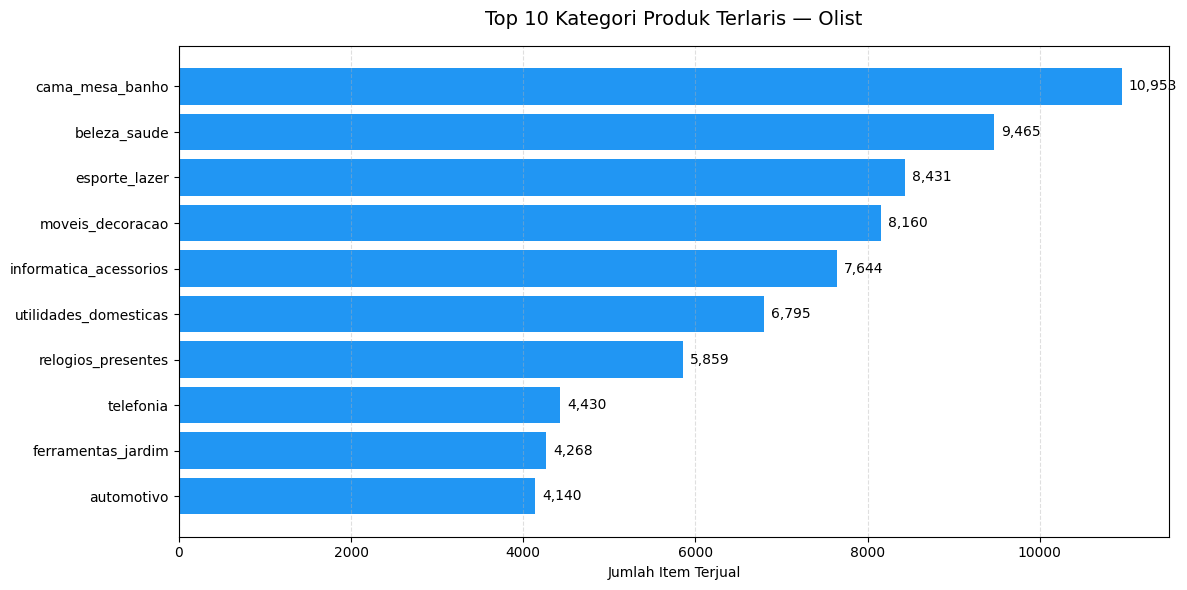

In [ ]:
top_kategori = (
    df['product_category_name']
    .value_counts()
    .head(10)
    .reset_index()
)
top_kategori.columns = ['kategori', 'jumlah_terjual']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_kategori['kategori'][::-1],
               top_kategori['jumlah_terjual'][::-1],
               color='#2196F3')

ax.set_title('Top 10 Kategori Produk Terlaris — Olist', fontsize=14, pad=15)
ax.set_xlabel('Jumlah Item Terjual')
ax.bar_label(bars, fmt='{:,.0f}', padding=5)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('top_kategori.png', dpi=150)
plt.show()

#INSIGHT
1. Produk rumah tangga paling laku
  (cama_mesa_banho) jadi produk ke 1 dengan 10.953 item. Hal ini terjadi karena merupakan kebutuhan semua orang, bukan barang musiman.
2. Beauty & Health di no 2
  Dari 9.465 item menunjukkan bahwa orang Brazil membeli skincare & produk kesehatan online dengan percaya diri. Segmentasi ini biasanya margin-nya juga bagus.
3. 5 kategori teratas semuanya berasal dari segmen lifestyle dan  rumah tangga, bukan elektronik atau teknologi. Hal ini menggambarkan profil konsumen Olist yang lebih berorientasi pada kebutuhan sehari-hari dibanding gadget.

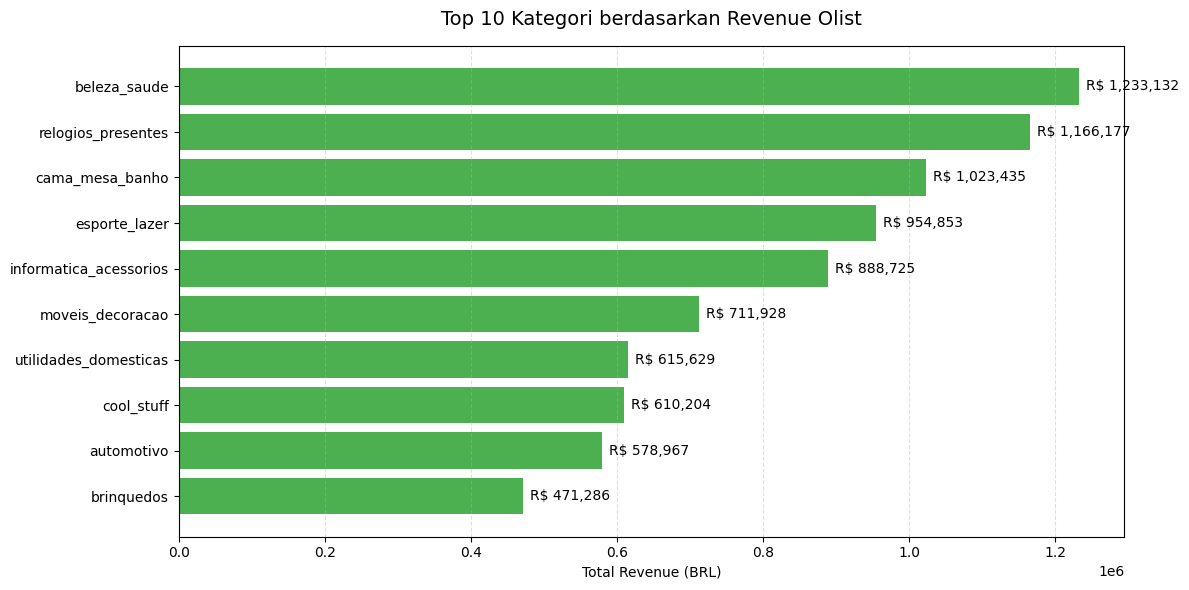

In [ ]:
#Revenue per kategori
revenue_kategori = (
    df.groupby('product_category_name')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
revenue_kategori.columns = ['kategori', 'total_revenue']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(revenue_kategori['kategori'][::-1],
               revenue_kategori['total_revenue'][::-1],
               color='#4CAF50')

ax.set_title('Top 10 Kategori berdasarkan Revenue Olist', fontsize=14, pad=15)
ax.set_xlabel('Total Revenue (BRL)')
ax.bar_label(bars, fmt='R$ {:,.0f}', padding=5)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('revenue_kategori.png', dpi=150)
plt.show()

#INSIGHT
1. Beleza_saude naik ke posisi 1 dengan revenue sebesar R$ 1.233.132, padahal di grafik volume terjual ada di posisi ke 2. Hal ini menunjukan bahwa produk kecantikan & kesehatan memiliki harga rata-rata per item yang lebih tinggi dibanding kategori lain.
2. Relogios_presentes (jam tangan dan hadiah) masuk top 2 revenue dengan (R$ 1.166.177), padahal pada grafik sebelumnya tidak masuk top 5. Ini adalah hal penting, karena kategori ini terjual lebih sedikit tapi menghasilkan uang lebih banyak, artinya harga per produknya tinggi.
3. Cama_mesa_banho yang sebelumnya diposisi 1 volume, turun ke posisi 3 revenue (R$ 1.023.435). Produknya paling laku tapi harga satuannya relatif lebih murah dibanding kategori jam tangan atau kecantikan.

Kesimpulan :
Volume terjual bukan berarti Revenue tertinggi. Karena tebukti pada kategori dengan harga produk premium seperti jam tangan dan kecantikan dapat menghasilkan pendapatan lebih besar meski jumlah itemnya lebih sedikit.

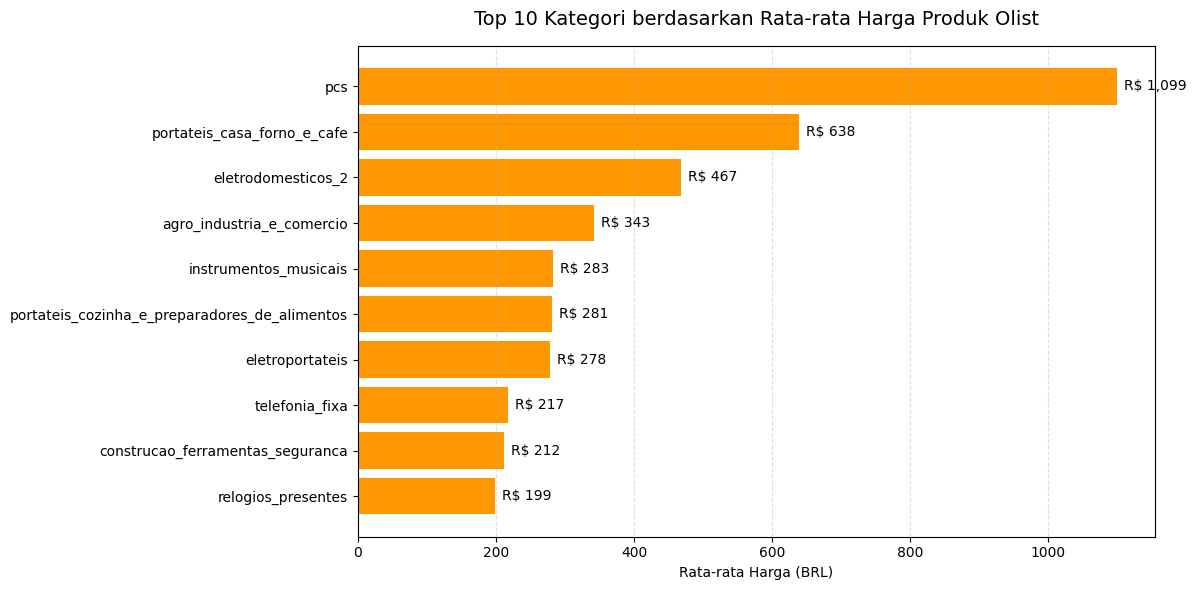

In [ ]:
avg_price = (
    df.groupby('product_category_name')['price']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
avg_price.columns = ['kategori', 'avg_price']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(avg_price['kategori'][::-1],
               avg_price['avg_price'][::-1],
               color='#FF9800')

ax.set_title('Top 10 Kategori berdasarkan Rata-rata Harga Produk Olist', fontsize=14, pad=15)
ax.set_xlabel('Rata-rata Harga (BRL)')
ax.bar_label(bars, fmt='R$ {:,.0f}', padding=5)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('avg_price.png', dpi=150)
plt.show()

#INSIGHT
1. Kategori pcs (komputer/PC) mempunyai rata-rata harga tertinggi sebesar R$ 1.099, jauh diatas kategori lainnya. Namun kategori ini tidak muncul di top 10 volume maupun revenue, yang berarti jumlah pembelinya sangat sedikit, yang berarti produk mahal tapi niche.
2. Relogios_presentes (jam tangan & hadiah) ada di posisi ke 10 dengan rata-rata harga dengan R$ 199, bukan yang tertinggi. Artinya revenue-nya besar bukan karena harga per item mahal, melainkan karena volume yang cukup banyak dengan harga menengah, sehingga menjadi kombinasi yang efektif.
3. Kategori elektronik rumah tangga mendominasi daftar harga tertinggi seperti eletrodomesticos, portateis, eletroportateis. tapi tidak ada di top revenue karena pembelinya terbatas.

Kesimpulan:
Kategori dengan revenue terbesar di Olist bukan yang harganya paling mahal, melainkan yang berhasil menjaga keseimbangan antara volume dan harga menengah seperti beleza_saude dan relogios_presentes.

In [ ]:
import datetime

#Tentukan tanggal(hari setelah transaksi terakhir)
snapshot_date = df['order_purchase_timestamp'].max() + datetime.timedelta(days=1)

#Gabungkan dengan data customer
rfm = df.groupby('customer_id').agg(
    recency=('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('price', 'sum')
).reset_index()

print(rfm.shape)
rfm.head()

(96478, 4)


,customer_id,recency,frequency,monetary
0,00012a2ce6f8dcda20d059ce98491703,288,1,89.80
1,000161a058600d5901f007fab4c27140,410,1,54.90
2,0001fd6190edaaf884bcaf3d49edf079,548,1,179.99
3,0002414f95344307404f0ace7a26f1d5,379,1,149.90
4,000379cdec625522490c315e70c7a9fb,150,1,93.00


In [ ]:
rfm['R_score'] = pd.qcut(rfm['recency'], q=4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['monetary'], q=4, labels=[1,2,3,4])

rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

print(rfm[['customer_id','recency','frequency','monetary','RFM_score']].head(10))

                        customer_id  recency  frequency  monetary RFM_score
0  00012a2ce6f8dcda20d059ce98491703      288          1     89.80       213
1  000161a058600d5901f007fab4c27140      410          1     54.90       112
2  0001fd6190edaaf884bcaf3d49edf079      548          1    179.99       114
3  0002414f95344307404f0ace7a26f1d5      379          1    149.90       113
4  000379cdec625522490c315e70c7a9fb      150          1     93.00       313
5  0004164d20a9e969af783496f3408652      505          1     59.99       112
6  000419c5494106c306a97b5635748086      180          1     34.30       311
7  00046a560d407e99b969756e0b10f282      255          1    120.90       213
8  00050bf6e01e69d5c0fd612f1bcfb69c      346          1     69.99       212
9  000598caf2ef4117407665ac33275130       19          1   1107.00       414


In [ ]:
def segment_customer(score):
    r = int(score[0])
    f = int(score[1])
    m = int(score[2])

    if r >= 3 and f >= 3 and m >= 3:
        return 'Champions'
    elif r >= 3 and f >= 2:
        return 'Loyal Customers'
    elif r >= 3 and f <= 2:
        return 'Potential Loyalist'
    elif r == 2 and f >= 2:
        return 'At Risk'
    elif r == 1 and f >= 2:
        return 'Lost Loyal'
    else:
        return 'Lost'

rfm['segment'] = rfm['RFM_score'].apply(segment_customer)
print(rfm['segment'].value_counts())

segment
Loyal Customers       23911
At Risk               18132
Lost Loyal            18031
Champions             12284
Potential Loyalist    12105
Lost                  12015
Name: count, dtype: int64


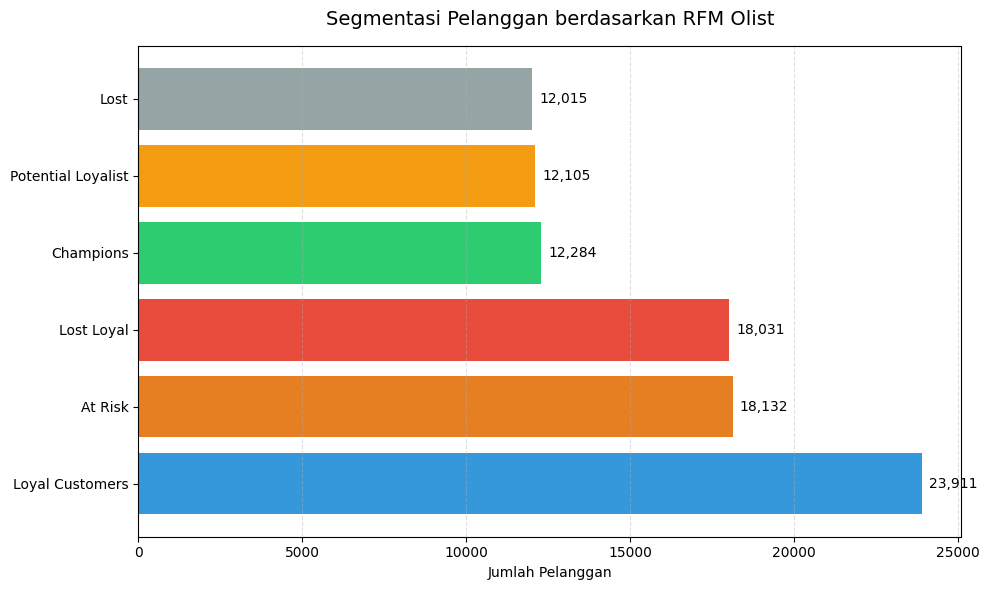

In [ ]:
segment_count = rfm['segment'].value_counts().reset_index()
segment_count.columns = ['segment', 'jumlah']

colors = {
    'Champions': '#2ecc71',
    'Loyal Customers': '#3498db',
    'Potential Loyalist': '#f39c12',
    'At Risk': '#e67e22',
    'Lost Loyal': '#e74c3c',
    'Lost': '#95a5a6'
}

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    segment_count['segment'],
    segment_count['jumlah'],
    color=[colors[s] for s in segment_count['segment']]
)

ax.set_title('Segmentasi Pelanggan berdasarkan RFM Olist', fontsize=14, pad=15)
ax.set_xlabel('Jumlah Pelanggan')
ax.bar_label(bars, fmt='{:,.0f}', padding=5)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('rfm_segmen.png', dpi=150)
plt.show()

#INSIGHT
1. Loyal Customers menjadi segmen terbesar dengan 23.911 pelanggan dimana 24,8% dari total. Hal ini baik karena hampir seperempat pelanggan Olist masih aktif dan konsisten bertransaksi.
2. Segmen At Risk dan Lost Loyal secara gabungan mencapai 36.163 pelanggan (37,5%). Hal ini menunjukan lebih dari sepertiga pelanggan yang pernah aktif kini mulai menjauh atau sudah tidak bertransaksi sama sekali. Segmen ini perlu diprioritaskan untuk program retensi.
3. Champions hanya 12.284 pelanggan (12,7%). Jumlahnya relatif kecil, namun segmen ini adalah pelanggan dengan nilai transaksi tertinggi dan frekuensi belanja paling sering, sehingga kontribusi revenue-nya kemungkinan jauh lebih besar dari proporsinya.

Rekomendasi :

pertahankan dengan program loyalitas atau exclusive offers
aktifkan kembali dengan promo atau reminder
evaluasi apakah cost reakuisisi masih worth it